# 02 Model Training

**Goal**: Train an XGBoost classifier and understand every design decision.

Design decisions made here:
1. Why XGBoost over Random Forest or Logistic Regression
2. Why `scale_pos_weight` instead of SMOTE oversampling
3. Why AUPRC is the right metric (not accuracy, not AUC-ROC)
4. Why we scale only Time and Amount

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

RANDOM_STATE = 42

df = pd.read_csv('../data/creditcard.csv')
print(f'Loaded {len(df):,} rows')

Loaded 284,807 rows


## 1. Preprocessing

**Only Time and Amount are scaled**, V1-V28 are PCA output, already zero-centered and unit-variance.
Scaling them again would be redundant at best, distorting at worst.

We fit the scaler **only on the training set** to prevent data leakage.

In [9]:
feature_cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df[feature_cols].copy()
y = df['Class'].values

# Stratified split — preserves fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit scaler on train only — avoid leakage
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train fraud rate: {y_train.mean():.4f} | Test fraud rate: {y_test.mean():.4f}')

Train: 227,845 | Test: 56,962
Train fraud rate: 0.0017 | Test fraud rate: 0.0017


Fraud rates match — stratification worked correctly

## 2. Why not SMOTE?

SMOTE creates synthetic fraud samples by interpolating between real ones.
The problem: interpolated fraud patterns may not reflect real fraud behavior.
XGBoost's `scale_pos_weight` achieves the same balancing effect by weighting the loss function, no synthetic data needed.

`scale_pos_weight = n_negative / n_positive`

In [3]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'Negative (legit): {n_neg:,}')
print(f'Positive (fraud): {n_pos:,}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')
print(f'Meaning: each fraud sample is weighted as if it were {scale_pos_weight:.0f} legit samples')

Negative (legit): 227,451
Positive (fraud): 394
scale_pos_weight: 577.3
Meaning: each fraud sample is weighted as if it were 577 legit samples


## 3. Baseline: Logistic Regression

Always establish a baseline before reaching for a complex model.
If XGBoost barely beats logistic regression, we may not need it.

In [4]:
lr = LogisticRegression(
    class_weight='balanced',   # equivalent of scale_pos_weight for sklearn
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_auprc = average_precision_score(y_test, lr_prob)

print(f'Logistic Regression AUPRC: {lr_auprc:.4f}')
print(f'Random classifier baseline: {y_test.mean():.4f}')

Logistic Regression AUPRC: 0.7159
Random classifier baseline: 0.0017


## 4. XGBoost Model

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,           # use 80% of data per tree — reduces overfitting
    colsample_bytree=0.8,    # use 80% of features per tree
    eval_metric='aucpr',     # optimize for AUPRC directly
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(X_train, y_train, verbose=False)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auprc = average_precision_score(y_test, xgb_prob)

print(f'XGBoost AUPRC:             {xgb_auprc:.4f}')
print(f'Logistic Regression AUPRC: {lr_auprc:.4f}')
print(f'Improvement over baseline: {((xgb_auprc - lr_auprc) / lr_auprc * 100):.1f}%')

XGBoost AUPRC:             0.8668
Logistic Regression AUPRC: 0.7159
Improvement over baseline: 21.1%


## 5. Feature Importance

Which PCA components does the model actually rely on?
Consistent with our EDA — V14, V17, V4 are usually most important.

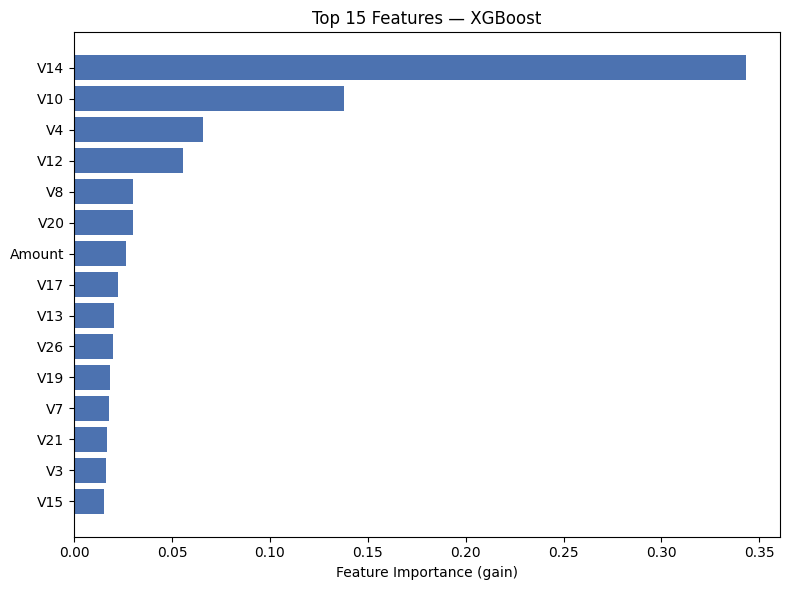

In [6]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='#4C72B0')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 15 Features — XGBoost')
plt.tight_layout()
plt.show()

## 6. Cross-Validation

Confirm the model isn't overfit to our specific train/test split.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use a faster model config for CV (fewer trees)
xgb_cv = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

cv_scores = cross_val_score(xgb_cv, X_train, y_train, 
                             cv=cv, scoring='average_precision', n_jobs=-1)
print(f'5-Fold CV AUPRC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds: {[f"{s:.4f}" for s in cv_scores]}')
print('\nLow variance across folds = model generalizes well, not overfit')

5-Fold CV AUPRC: 0.8273 ± 0.0190
Individual folds: ['0.8297', '0.7997', '0.8126', '0.8443', '0.8502']

Low variance across folds = model generalizes well, not overfit


## 7. Save Artifacts

In [8]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_model, '../models/fraud_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')

print('Saved: models/fraud_model.joblib')
print('Saved: models/scaler.joblib')
print('\nThreshold tuning and final evaluation → see 03_evaluation.ipynb')

Saved: models/fraud_model.joblib
Saved: models/scaler.joblib

Threshold tuning and final evaluation → see 03_evaluation.ipynb
